# 09 - GPU Multiprocessing Compile Benchmark

목표:
- 10~15 큐비트 규모에서 PPS compile을 수행
- `gpu_parallel=False/True`(=`parallel_compile`)로 compile 시간 비교
- compile 동안 GPU별 사용량(활용률/메모리) 피크를 비교

이 노트북은 `compile_expval_program(...)`의 `parallel_compile` 옵션을 멀티 GPU 관점에서 비교합니다.

- `gpu_parallel=False` -> 단일 경로 compile
- `gpu_parallel=True` -> 병렬 compile 경로

참고: GPU 개수가 1개라면 병렬 이점은 제한적일 수 있습니다.

In [2]:
from pathlib import Path
import sys
import time
import threading
import subprocess

import numpy as np
import torch
import matplotlib.pyplot as plt

root = Path.cwd()
if not (root / 'src').exists():
    root = root.parent
sys.path.insert(0, str(root))

from src.pauli_surrogate_python import CliffordGate, PauliRotation, PauliSum
from src_tensor.api import compile_expval_program

print('repo root:', root)
print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
print('gpu count:', torch.cuda.device_count() if torch.cuda.is_available() else 0)

repo root: /home/ubuntu/PPS-lab
torch: 2.2.0+cu121
cuda available: True
gpu count: 4


In [3]:
def make_ring_chord_edges(n_qubits: int, chord_shift: int = 5):
    edges = set()
    for i in range(n_qubits):
        a, b = i, (i + 1) % n_qubits
        edges.add((a, b) if a < b else (b, a))

        c, d = i, (i + chord_shift) % n_qubits
        edges.add((c, d) if c < d else (d, c))
    return sorted(edges)


def build_benchmark_case(n_qubits: int = 12, p_layers: int = 3, chord_shift: int = 5, device: str = 'cpu'):
    edges = make_ring_chord_edges(n_qubits, chord_shift=chord_shift)

    circuit = []
    for q in range(n_qubits):
        circuit.append(CliffordGate('H', [q]))

    param_idx = 0
    for _ in range(p_layers):
        for (u, v) in edges:
            circuit.append(PauliRotation('ZZ', [u, v], param_idx=param_idx))
            param_idx += 1
        for q in range(n_qubits):
            circuit.append(PauliRotation('X', [q], param_idx=param_idx))
            param_idx += 1

    objective = PauliSum(n_qubits)
    for (u, v) in edges:
        objective.add_from_str('ZZ', 1.0, qubits=[u, v])

    observables = [objective]
    thetas = torch.randn(param_idx, dtype=torch.float64, device=device) * 0.1

    return {
        'n_qubits': n_qubits,
        'p_layers': p_layers,
        'n_edges': len(edges),
        'n_params': param_idx,
        'circuit': circuit,
        'observables': observables,
        'thetas': thetas,
    }


def query_gpus_nvidia_smi():
    if not torch.cuda.is_available():
        return []

    cmd = [
        'nvidia-smi',
        '--query-gpu=index,name,utilization.gpu,memory.used,memory.total',
        '--format=csv,noheader,nounits',
    ]
    try:
        out = subprocess.check_output(cmd, text=True)
    except Exception:
        return []

    rows = []
    for line in out.strip().splitlines():
        parts = [p.strip() for p in line.split(',')]
        if len(parts) < 5:
            continue
        rows.append({
            'index': int(parts[0]),
            'name': parts[1],
            'util': float(parts[2]),
            'mem_used': float(parts[3]),
            'mem_total': float(parts[4]),
        })
    return rows


def summarize_gpu_samples(samples):
    peak = {}
    for rows in samples:
        for row in rows:
            idx = row['index']
            if idx not in peak:
                peak[idx] = {
                    'name': row['name'],
                    'peak_util': row['util'],
                    'peak_mem_used': row['mem_used'],
                    'mem_total': row['mem_total'],
                }
            else:
                peak[idx]['peak_util'] = max(peak[idx]['peak_util'], row['util'])
                peak[idx]['peak_mem_used'] = max(peak[idx]['peak_mem_used'], row['mem_used'])
    return peak

In [4]:
def run_compile_once(*, gpu_parallel: bool, case, preset: str = 'hybrid'):
    gpu_samples = []
    stop_event = threading.Event()

    def monitor_loop():
        while not stop_event.is_set():
            rows = query_gpus_nvidia_smi()
            if rows:
                gpu_samples.append(rows)
            time.sleep(0.2)

    monitor_thread = threading.Thread(target=monitor_loop, daemon=True)
    monitor_thread.start()

    start = time.perf_counter()
    program = compile_expval_program(
        circuit=case['circuit'],
        observables=case['observables'],
        preset=preset,
        build_thetas=case['thetas'],
        build_min_abs=1e-8,
        parallel_compile=gpu_parallel,
    )
    elapsed = time.perf_counter() - start

    stop_event.set()
    monitor_thread.join(timeout=1.0)

    gpu_peak = summarize_gpu_samples(gpu_samples)

    return {
        'gpu_parallel': gpu_parallel,
        'compile_sec': elapsed,
        'gpu_peak': gpu_peak,
        'program': program,
    }


def print_gpu_peak(label: str, gpu_peak: dict):
    print(f'\n[{label}] GPU peak usage')
    if not gpu_peak:
        print('  (no GPU sample: CUDA or nvidia-smi unavailable)')
        return
    for idx in sorted(gpu_peak.keys()):
        p = gpu_peak[idx]
        print(
            f"  GPU {idx} ({p['name']}): util_peak={p['peak_util']:.1f}% | "
            f"mem_peak={p['peak_mem_used']:.0f} MiB / {p['mem_total']:.0f} MiB"
        )

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

n_qubits = 15
p_layers = 4

case = build_benchmark_case(n_qubits=n_qubits, p_layers=p_layers, chord_shift=5, device=device)
print({k: case[k] for k in ['n_qubits', 'p_layers', 'n_edges', 'n_params']})

preset = 'hybrid' if torch.cuda.is_available() else 'cpu'

results = []
programs = {}
for gpu_parallel in [False, True]:
    print(f'\n=== compile_expval_program(gpu_parallel={gpu_parallel}) ===')
    out = run_compile_once(gpu_parallel=gpu_parallel, case=case, preset=preset)
    results.append(out)
    programs[gpu_parallel] = out['program']
    print(f"compile_sec: {out['compile_sec']:.3f}s")
    print_gpu_peak(f'gpu_parallel={gpu_parallel}', out['gpu_peak'])

if torch.cuda.is_available() and torch.cuda.device_count() < 2:
    print('\n[Note] GPU가 1개이므로 parallel_compile=True의 멀티 GPU 이점은 제한적일 수 있습니다.')

{'n_qubits': 15, 'p_layers': 4, 'n_edges': 30, 'n_params': 180}

=== compile_expval_program(gpu_parallel=False) ===


propagate: 100%|██████████| 195/195 [00:03<00:00, 59.16it/s]


[PPS Info] Propagation complete. Terms generated: 49,440
Starting zero-filtering on cuda...
[ZeroFilter] Initial pruning (diagonal terms only): 49,440 -> 166 terms kept (0.33576052%)
[ZeroFilter] Zero-filtering done. Starting back-propagation of keep mask through 195 steps...


zero-filter: 100%|██████████| 195/195 [00:25<00:00,  7.51it/s, step=0 rows=34 cols=30]       


compile_sec: 29.282s

[gpu_parallel=False] GPU peak usage
  GPU 0 (Tesla T4): util_peak=47.0% | mem_peak=131 MiB / 15360 MiB
  GPU 1 (Tesla T4): util_peak=0.0% | mem_peak=3 MiB / 15360 MiB
  GPU 2 (Tesla T4): util_peak=0.0% | mem_peak=3 MiB / 15360 MiB
  GPU 3 (Tesla T4): util_peak=0.0% | mem_peak=3 MiB / 15360 MiB

=== compile_expval_program(gpu_parallel=True) ===
[PPS Info] Auto-configuring parallel threshold for 14.6GB GPU: 61,086,464 terms.
[PPS Info] Compiling in parallel across 4 GPUs (['cuda:0', 'cuda:1', 'cuda:2', 'cuda:3']).


propagate: 100%|██████████| 195/195 [00:03<00:00, 59.22it/s]


[PPS Info] Propagation complete. Terms generated: 49,440
Starting zero-filtering on cuda...
[ZeroFilter] Initial pruning (diagonal terms only): 49,440 -> 166 terms kept (0.33576052%)
[ZeroFilter] Zero-filtering done. Starting back-propagation of keep mask through 195 steps...


zero-filter: 100%|██████████| 195/195 [00:25<00:00,  7.53it/s, step=0 rows=34 cols=30]       


compile_sec: 29.199s

[gpu_parallel=True] GPU peak usage
  GPU 0 (Tesla T4): util_peak=52.0% | mem_peak=131 MiB / 15360 MiB
  GPU 1 (Tesla T4): util_peak=0.0% | mem_peak=3 MiB / 15360 MiB
  GPU 2 (Tesla T4): util_peak=0.0% | mem_peak=3 MiB / 15360 MiB
  GPU 3 (Tesla T4): util_peak=0.0% | mem_peak=3 MiB / 15360 MiB



Compile time summary
  gpu_parallel=False : 29.282s
  gpu_parallel=True  : 29.199s
  speedup (False/True): 1.003x


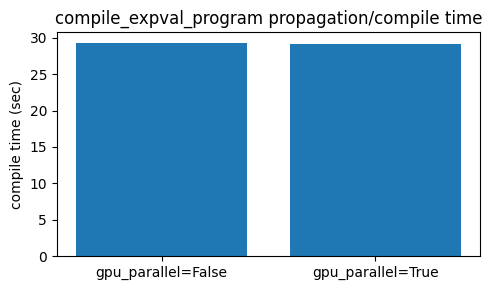

In [9]:
times = {r['gpu_parallel']: r['compile_sec'] for r in results}

print('\nCompile time summary')
print(f"  gpu_parallel=False : {times[False]:.3f}s")
print(f"  gpu_parallel=True  : {times[True]:.3f}s")
if times[False] > 0:
    speedup = times[False] / times[True]
    print(f"  speedup (False/True): {speedup:.3f}x")

plt.figure(figsize=(5, 3))
plt.bar(['gpu_parallel=False', 'gpu_parallel=True'], [times[False], times[True]])
plt.ylabel('compile time (sec)')
plt.title('compile_expval_program propagation/compile time')
plt.tight_layout()
plt.show()

In [10]:
# 같은 입력(theta)에서 compile 결과의 expval 일관성 체크
v_false = programs[False].expvals(case['thetas'])
v_true = programs[True].expvals(case['thetas'])

max_abs_diff = float(torch.max(torch.abs(v_false.detach().cpu() - v_true.detach().cpu())))
print('expval(false):', v_false.detach().cpu().numpy())
print('expval(true) :', v_true.detach().cpu().numpy())
print(f'max abs diff : {max_abs_diff:.6e}')

expval(false): [-0.08052577]
expval(true) : [-0.08052577]
max abs diff : 0.000000e+00


## Reading guide
- `compile_sec`: `compile_expval_program` 전체 시간(전파 + zero-filter + basis shrink 포함)
- `GPU peak usage`: compile 구간 동안 `nvidia-smi` 기준 GPU별 피크 활용률/메모리
- 환경에 따라 `gpu_parallel=True`가 항상 빠르지 않을 수 있습니다(문제 크기, GPU 수, I/O/스케줄링 영향).
- `parallel_compile=True`여도 GPU 1개의 VRAM 사용량이 일정 수준에 못 미치면 실질 병렬 처리가 발생하지 않을 수 있으며, 이 경우 속도 향상은 기대하기 어렵습니다.

실험 팁:
- 더 무거운 실험: `n_qubits=14~15`, `p_layers=4`로 증가
- 메모리 여유가 충분하면 `preset='gpu'`로 바꿔서 비교
- 재현성 강화를 위해 `torch.manual_seed(...)`를 고정